# Guía práctica 1

## Ejercicio 4 (a)

### Linealidad del sistema

Si el sistema es lineal, entonces la transformación de una combinación lineal de entradas debe ser igual a la combinación lineal de las transformaciones de esas entradas:

$$
y_3[n] = \alpha y_1[n] + \beta y_2[n] = H\{x_3[n]\} = H\{\alpha x_1[n] + \beta x_2[n]\}
$$

Luego, defino $y_1[n]$ e $y_2[n]$:

$$
y_1[n] = -a_1 y_1[n-1] -a_2 y_1[n-2] + b_0 x_1[n] 
$$

$$
y_2[n] = -a_1 y_2[n-1] -a_2 y_2[n-2] + b_0 x_2[n] 
$$

Luego, calculo la combinación lineal de las salidas:

$$
\alpha y_1[n] + \beta y_2[n] = \alpha (-a_1 y_1[n-1] -a_2 y_1[n-2] + b_0 x_1[n]) + \beta (-a_1 y_2[n-1] -a_2 y_2[n-2] + b_0 x_2[n]) =
$$

$$
= -a_1 (\alpha y_1[n-1] + \beta y_2[n-1]) - a_2 (\alpha y_1[n-2] + \beta y_2[n-2]) + b_0 (\alpha x_1[n] + \beta x_2[n])
$$

$$
= -a_1 y_3[n-1] - a_2 y_3[n-2] + b_0 x_3[n]
$$

Estas ultimas expresiones muestran que la combinación lineal de las salidas es igual a la salida del sistema para la combinación lineal de las entradas, lo que confirma que el sistema es lineal.

### Invarianza temporal del sistema

La invarianza temporal se puede demostrar de manera similar. Si el sistema es invariante en el tiempo, entonces una entrada desplazada en el tiempo debe producir una salida desplazada en el tiempo de la misma manera:

$$
y[n-n_0] = H\{x[n-n_0]\}
$$

Para ello defino:

$$
x_4[n] = x[n-n_0]
$$

Luego, la salida correspondiente es:

$$
y_4[n] = -a_1 y_4[n-1] - a_2 y_4[n-2] + b_0 x_4[n] =
$$

$$
= -a_1 y[n-1] - a_2 y[n-2] + b_0 x[n-n_0]
$$

Luego, la salida desplazada de la entrada original es:

$$
y[n-n_0] = -a_1 y[n-n_0-1] - a_2 y[n-n_0-2] + b_0 x[n-n_0]
$$

Si se cumple que:

$$
y_4[n] = y[n-n_0]
$$

Entonces se puede definir:

$$
y_4[n-1] = y[n-n_0-1]
$$

$$ 
y_4[n-2] = y[n-n_0-2]
$$

Reemplazando estas expresiones en la ecuación de $y_4[n]$, se obtiene:

$$
y_4[n] = -a_1 y[n-n_0-1] - a_2 y[n-n_0-2] + b_0 x[n-n_0]
$$

Esta expresión es igual a la salida desplazada de la entrada original ($y[n-n_0]$), lo que confirma que el sistema es invariante en el tiempo.

## Ejercicio 4 (b)

In [1]:
from matplotlib.pyplot import (
    figure,
    grid,
    legend,
    plot,
    show,
    stem,
    ylim,
    title,
    xlabel,
    ylabel,
    scatter,
)
from numpy import arange, linspace, pi, sin, exp, sum, full, zeros, ceil, ones
from scipy.fftpack import fft
from scipy.signal import firwin, lfilter

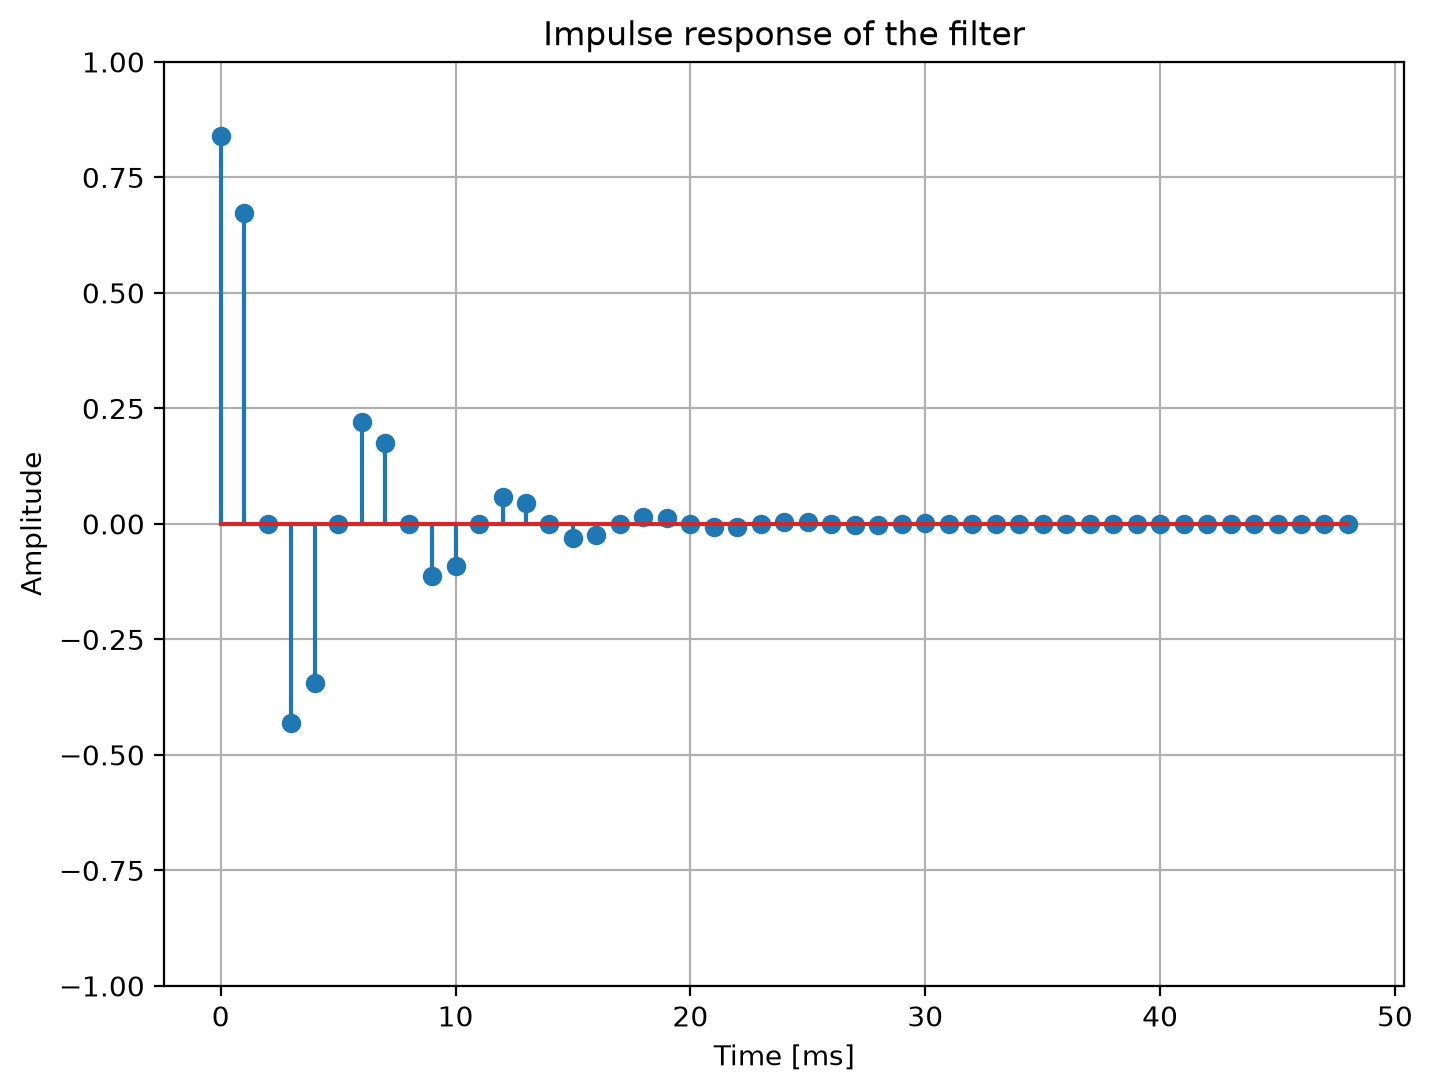

In [2]:
sampling_freq_hz = 1e3
n_samples = 49
duration_s = n_samples * 1 / sampling_freq_hz

t = arange(n_samples) / sampling_freq_hz
t_ms = t * 1e3

filter_a1 = -0.8
filter_a2 = 0.64
filter_b0 = 0.84

b = [filter_b0]
a = [1, filter_a1, filter_a2]

# System output
y = zeros(n_samples)

# System input (Kronecker delta)
x = zeros(n_samples)
x[0] = 1

# Manual implementation (alternative to lfilter)
# for k in range(n_samples):
#     y[k] += filter_b0 * x[k]
#     if k >= 1:
#         y[k] += -filter_a1 * y[k - 1]
#     if k >= 2:
#         y[k] += -filter_a2 * y[k - 2]

y = lfilter(b, a, x)

figure(1, figsize=(8, 6), dpi=200)
stem(t_ms, y)
ylim((-ceil(max(y)), ceil(max(y))))
xlabel("Time [ms]")
ylabel("Amplitude")
title("Impulse response of the filter")
grid(True)
show()

## Ejercicio 4 (c)

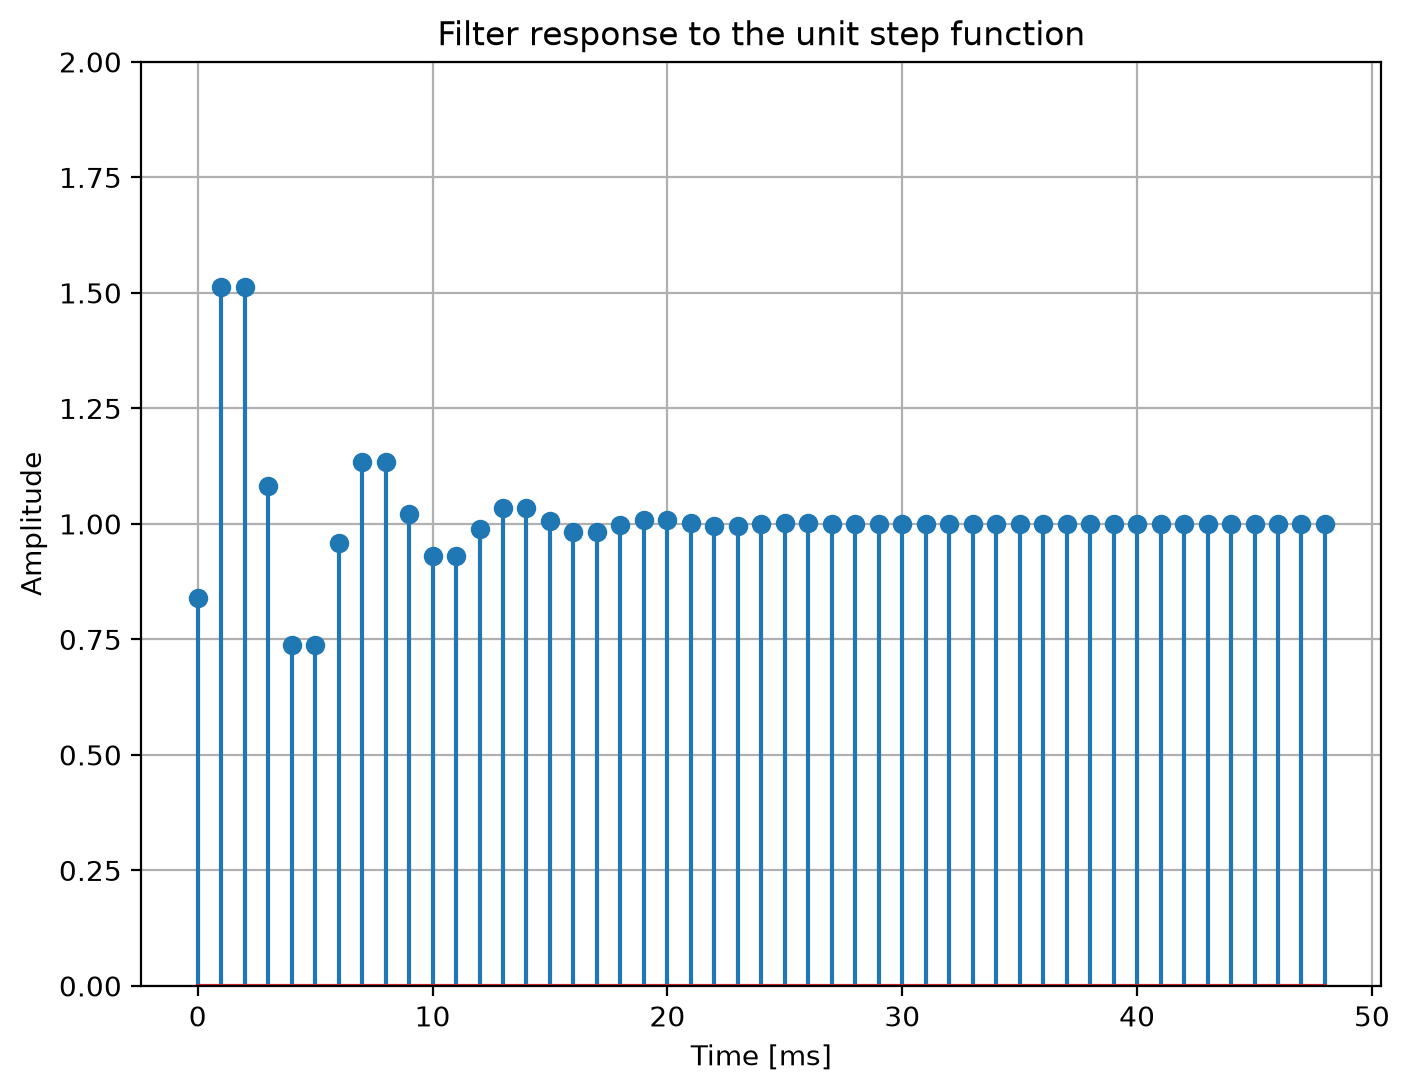

In [3]:
# System input (Kronecker delta)
x = ones(n_samples)

# System output
y = lfilter(b, a, x)

figure(1, figsize=(8, 6), dpi=200)
stem(t_ms, y)
ylim((0, ceil(max(y))))
xlabel("Time [ms]")
ylabel("Amplitude")
title("Filter response to the unit step function")
grid(True)
show()